In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [48]:
df = pd.read_csv('Iris.csv')

In [49]:
df.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [50]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [51]:
# to diaply basic info about dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [52]:
# how many classess does species(output) have
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [53]:
# to check if the data has any null values
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

<h2>EDA</h2>

<Axes: >

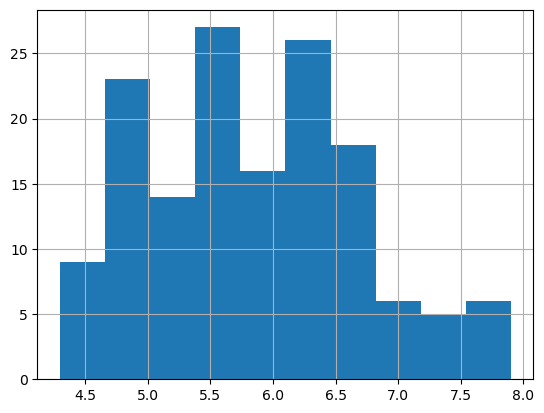

In [54]:
df['SepalLengthCm'].hist()

<Axes: >

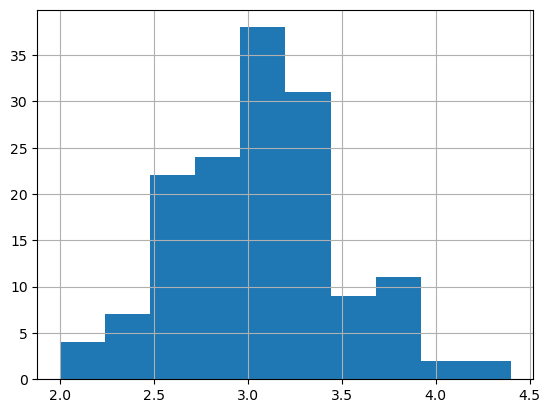

In [55]:
df['SepalWidthCm'].hist()

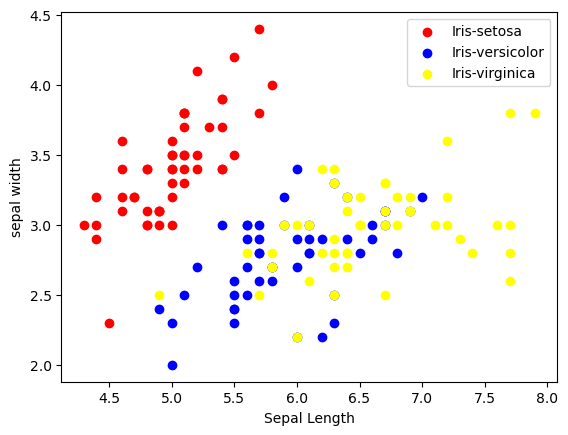

In [56]:
# SCATTER PLOT

colors = ['red','blue','yellow']  # for the colors of the scatter plot 
species = ['Iris-setosa','Iris-versicolor','Iris-virginica'] # for the species(outcome)

for i in range(3):
    x = df[df['Species'] == species[i]]
    plt.scatter(x['SepalLengthCm'],x['SepalWidthCm'], c = colors[i],label = species[i])
plt.xlabel('Sepal Length')
plt.ylabel('sepal width')
plt.legend() 

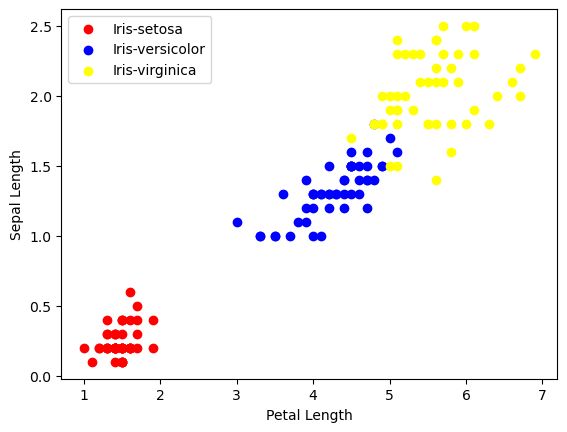

In [57]:
for i in range(3):
    y = df[df['Species'] == species[i]]     
    plt.scatter(y['PetalLengthCm'],y['PetalWidthCm'], c = colors[i] , label = species[i])
plt.xlabel('Petal Length')
plt.ylabel('Sepal Length')
plt.legend()


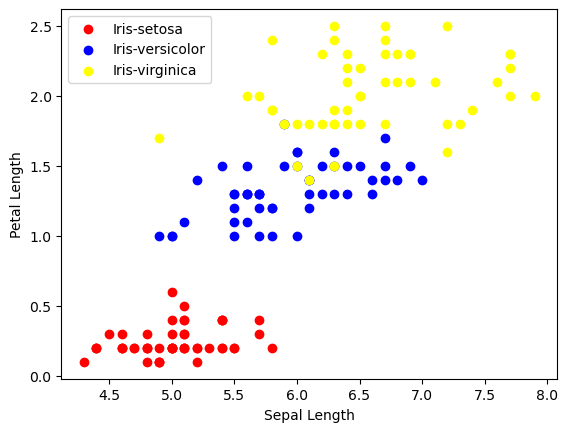

In [58]:
for i in range(3):
    y = df[df['Species'] == species[i]]     
    plt.scatter(y['SepalLengthCm'],y['PetalWidthCm'], c = colors[i] , label = species[i])
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.legend()


<h2>CORELATION MATRIX</h2>



In [59]:
df.corr(numeric_only = True)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,1.000000,0.716676,-0.397729,0.882747,0.899759
SepalLengthCm,0.716676,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.397729,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.882747,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.899759,0.817954,-0.356544,0.962757,1.000000


<Axes: >

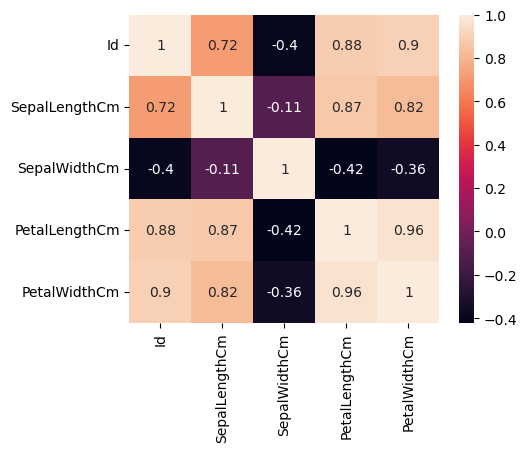

In [60]:
corr = df.corr(numeric_only = True)
fig , ax = plt.subplots(figsize = (5,4))
sns.heatmap(corr , annot = True , ax = ax)

<h2>LABEL ENCODING</h2>

In [61]:
from sklearn.preprocessing import LabelEncoder

In [62]:
le =  LabelEncoder()

In [63]:
df['Species']=le.fit_transform(df['Species'])

In [64]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [40]:
from sklearn.model_selection import train_test_split

In [66]:
x = df.drop(columns = ['Species'])
y = df['Species']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3)

In [68]:
from sklearn.linear_model import LogisticRegression

In [71]:
model = LogisticRegression()
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [74]:
model.fit(x_train,y_train)  # model traianig

E:\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [76]:
print("Accuracy: ",model.score(x_test,y_test))

Accuracy:  1.0


In [80]:
# to train it on decission trees
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [81]:
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [82]:
print("Accuracy : ", model.score(x_test,y_test))

Accuracy :  1.0
